In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("/content/KDDTrain+.txt", header=None)

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       125973 non-null  int64  
 1   1       125973 non-null  object 
 2   2       125973 non-null  object 
 3   3       125973 non-null  object 
 4   4       125973 non-null  int64  
 5   5       125973 non-null  int64  
 6   6       125973 non-null  int64  
 7   7       125973 non-null  int64  
 8   8       125973 non-null  int64  
 9   9       125973 non-null  int64  
 10  10      125973 non-null  int64  
 11  11      125973 non-null  int64  
 12  12      125973 non-null  int64  
 13  13      125973 non-null  int64  
 14  14      125973 non-null  int64  
 15  15      125973 non-null  int64  
 16  16      125973 non-null  int64  
 17  17      125973 non-null  int64  
 18  18      125973 non-null  int64  
 19  19      125973 non-null  int64  
 20  20      125973 non-null  int64  
 21  21      12

In [7]:
df.iloc[:5,[1,2,3,41]]

,1,2,3,41
0,tcp,ftp_data,SF,normal
1,udp,other,SF,normal
2,tcp,private,S0,neptune
3,tcp,http,SF,normal
4,tcp,http,SF,normal


In [8]:
df[41].value_counts() # so there are 22 types of network intrusions apart from normal

,count
41,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


## 5-Class Mapping

Normal,
DoS,
Probe,
R2L,
U2R

## DoS

1. back
2. land
3. neptune
4. pod
5. smurf
6. teardrop



## Probe

1. ipsweep
2.   nmap
3.   portsweep
4.   satan



## R2L


* ftp_write
* guess_passwd
* imap
* multihop
* phf
* spy
* warezclient
* warezmaster



## U2R

*   List item
* buffer_overflow
* loadmodule
* perl
* rootkit



class sizes are imbalanced

*   U2R ≈ 50
* Normal ≈ 67,000



In [9]:
attack_mapping = {
    # Normal
    "normal": "Normal",

    # DoS
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",

    # Probe
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "satan": "Probe",

    # R2L
    "ftp_write": "R2L",
    "guess_passwd": "R2L",
    "imap": "R2L",
    "multihop": "R2L",
    "phf": "R2L",
    "spy": "R2L",
    "warezclient": "R2L",
    "warezmaster": "R2L",

    # U2R
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "perl": "U2R",
    "rootkit": "U2R"
}

df["attack_class"] = df[41].map(attack_mapping)

In [10]:
class_counts = df["attack_class"].value_counts()
print(class_counts)

attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


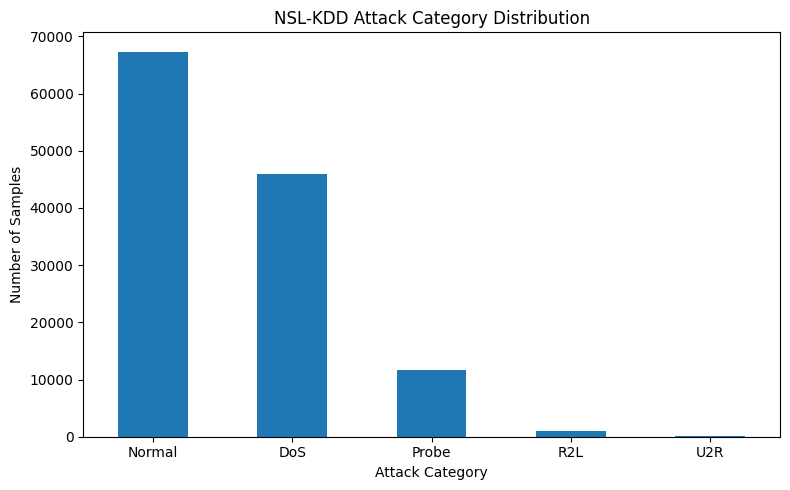

In [11]:
import matplotlib.pyplot as plt

class_counts = df["attack_class"].value_counts()

plt.figure(figsize=(8,5))
class_counts.plot(kind="bar")

plt.title("NSL-KDD Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Number of Samples")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [12]:
df.isnull().sum().sort_values(ascending=False) #checking for missing values

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [13]:
df.dtypes

,0
0,int64
1,object
2,object
3,object
4,int64
5,int64
6,int64
7,int64
8,int64
9,int64


In [14]:
df.describe()

,0,4,5,6,7,8,9,10,11,12,...,32,33,34,35,36,37,38,39,40,42
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [15]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty","attack_class"
]

In [16]:
df.columns=columns

In [17]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,attack_class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,Normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,Normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,DoS
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,Normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,Normal


In [18]:
df.columns = columns

print(df.shape)

print(df["protocol_type"].value_counts())

print(df["service"].value_counts().head(10))

print(df["flag"].value_counts())

print(df["attack_class"].value_counts())

(125973, 44)
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64
attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [19]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ["protocol_type", "service", "flag"]
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_features = encoder.fit_transform(df[categorical_cols])

In [20]:
encoded_column_names = encoder.get_feature_names_out(categorical_cols)

print(encoded_column_names)

['protocol_type_icmp' 'protocol_type_tcp' 'protocol_type_udp'
 'service_IRC' 'service_X11' 'service_Z39_50' 'service_aol' 'service_auth'
 'service_bgp' 'service_courier' 'service_csnet_ns' 'service_ctf'
 'service_daytime' 'service_discard' 'service_domain' 'service_domain_u'
 'service_echo' 'service_eco_i' 'service_ecr_i' 'service_efs'
 'service_exec' 'service_finger' 'service_ftp' 'service_ftp_data'
 'service_gopher' 'service_harvest' 'service_hostnames' 'service_http'
 'service_http_2784' 'service_http_443' 'service_http_8001'
 'service_imap4' 'service_iso_tsap' 'service_klogin' 'service_kshell'
 'service_ldap' 'service_link' 'service_login' 'service_mtp'
 'service_name' 'service_netbios_dgm' 'service_netbios_ns'
 'service_netbios_ssn' 'service_netstat' 'service_nnsp' 'service_nntp'
 'service_ntp_u' 'service_other' 'service_pm_dump' 'service_pop_2'
 'service_pop_3' 'service_printer' 'service_private' 'service_red_i'
 'service_remote_job' 'service_rje' 'service_shell' 'service_smtp'
 

In [21]:
import pandas as pd

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoded_column_names,
    index=df.index
)

In [22]:
df_numeric = df.drop(columns=categorical_cols)

In [23]:
df_final = pd.concat(
    [df_numeric, encoded_df],
    axis=1
)

In [24]:
print(df_final.shape)
df_final.head()

(125973, 125)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,146,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,232,8153,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,199,420,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## No need of standardization needed for Random Forests(Decision trees)

In [45]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=200, max_depth=None,
    min_samples_split=2, random_state=0)

In [46]:
x=df_final.drop(columns=["attack_class", "label"])

In [47]:
y=df_final['attack_class']

In [48]:
y=y.map({"Normal":0,"DoS":1,"Probe":2,"R2L":3,"U2R":4})

In [49]:
clf.fit(x,y)

RandomForestClassifier(n_estimators=200, random_state=0)

In [50]:
df1=pd.read_csv("/content/KDDTest+.txt", header=None)

In [51]:
df1.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [52]:
df1.columns = columns[:-1]

In [53]:
df1.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [54]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Categorical columns
categorical_cols = ["protocol_type", "service", "flag"]

# Create encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit on TRAIN and transform TRAIN
train_encoded = encoder.fit_transform(df[categorical_cols])

# Transform TEST using SAME encoder
test_encoded = encoder.transform(df1[categorical_cols])

# Get generated column names
encoded_cols = encoder.get_feature_names_out(categorical_cols)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoded_cols,
    index=df1.index
)

df_test_numeric = df1.drop(columns=categorical_cols)


df_test_final = pd.concat(
    [df_test_numeric, test_encoded_df],
    axis=1
)

print("Test shape:", df_test_final.shape)

Test shape: (22544, 124)


In [55]:
df_test_final.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,12983,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,20,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,0,15,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
x_test=df_test_final.drop(columns=[ "label"])

In [57]:
y_test=df_test_final['label'].map(attack_mapping).fillna('Normal').map({"Normal":0,"DoS":1,"Probe":2,"R2L":3,"U2R":4})

In [58]:
y_test.head()

,label
0,1
1,1
2,0
3,0
4,0


In [59]:
y_pred=clf.predict(x_test)

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

In [61]:
accuracy

0.8508250532292406

### Additional Classification Metrics

In [62]:
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Precision: 0.8678
Recall: 0.8508
F1-Score: 0.8134


### Confusion Matrix

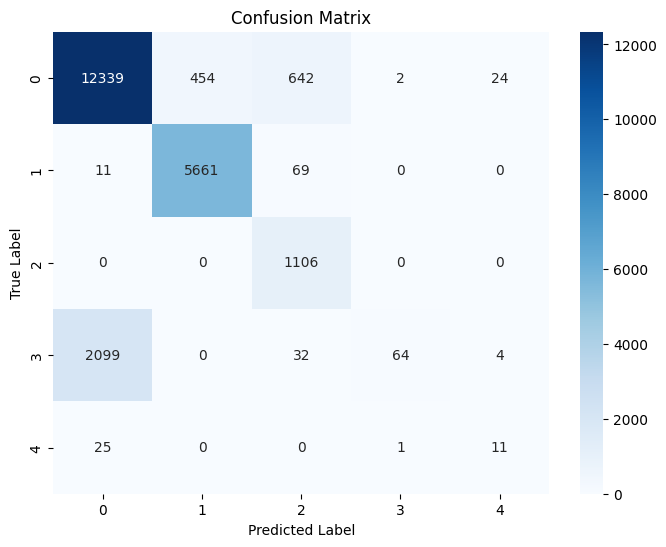

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

here R2L(3) is a disaster and U2R(4) also performed bad probe(2) is perfectly classified and normal(0) and Dos(1) are good

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88     13461
           1       0.93      0.99      0.95      5741
           2       0.60      1.00      0.75      1106
           3       0.96      0.03      0.06      2199
           4       0.28      0.30      0.29        37

    accuracy                           0.85     22544
   macro avg       0.72      0.65      0.59     22544
weighted avg       0.87      0.85      0.81     22544



## Future importance analysis